In [17]:
import pandas as pd
import numpy as np
df=pd.read_csv("C:\\Users\\ACER\\Downloads\\BigMart Sales.csv")

In [31]:
class DataHandler:

    def preprocess(self,df):


        df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)
        df['Item_Visibility'] = df['Item_Visibility'].replace(0, np.nan)
        df['Item_Visibility'].fillna(df['Item_Visibility'].mean(), inplace=True)

    def calculate_age(self,df):
        CURRENT_YEAR = 2026
        df['Outlet_Age'] = CURRENT_YEAR - df['Outlet_Establishment_Year']
        df['Outlet_Age']


    def remove_outlier(self,df):
        Q1 = df['Item_Outlet_Sales'].quantile(0.25)
        Q3 = df['Item_Outlet_Sales'].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df = df[(df['Item_Outlet_Sales'] >= lower) & (df['Item_Outlet_Sales'] <= upper)]


    def data_normalizer(self,df):
        df['Normalized_Sales'] = (
            (df['Item_Outlet_Sales'] - np.mean(df['Item_Outlet_Sales'])) /
            np.std(df['Item_Outlet_Sales'])
        )

        df['Rolling_Sales'] = df['Item_Outlet_Sales'].rolling(5).mean()



In [18]:

df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)
df['Item_Visibility'] = df['Item_Visibility'].replace(0, np.nan)
df['Item_Visibility'].fillna(df['Item_Visibility'].mean(), inplace=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_1000\1694655856.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)
C:\Users\ACER\AppData\Local\Temp\ipykernel_1000\1694655856.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chaine

0       0.016047
1       0.019278
2       0.016760
3       0.070482
4       0.070482
          ...   
8518    0.056783
8519    0.046982
8520    0.035186
8521    0.145221
8522    0.044878
Name: Item_Visibility, Length: 8523, dtype: float64

In [26]:
CURRENT_YEAR = 2026
df['Outlet_Age'] = CURRENT_YEAR - df['Outlet_Establishment_Year']
df['Outlet_Age']

0       27
1       17
2       27
3       28
4       39
        ..
8518    39
8519    24
8520    22
8521    17
8522    29
Name: Outlet_Age, Length: 8337, dtype: int64

In [20]:
Q1 = df['Item_Outlet_Sales'].quantile(0.25)
Q3 = df['Item_Outlet_Sales'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Item_Outlet_Sales'] >= lower) & (df['Item_Outlet_Sales'] <= upper)]

In [21]:

df['Normalized_Sales'] = (
    (df['Item_Outlet_Sales'] - np.mean(df['Item_Outlet_Sales'])) /
    np.std(df['Item_Outlet_Sales'])
)

df['Rolling_Sales'] = df['Item_Outlet_Sales'].rolling(5).mean()

In [22]:
avg_sales = df.groupby(['Outlet_Identifier', 'Item_Identifier'])['Item_Outlet_Sales'].mean()
print(avg_sales.head())

Outlet_Identifier  Item_Identifier
OUT010             DRA12              283.6308
                   DRA24              327.5736
                   DRA59              185.0924
                   DRB13              948.7650
                   DRB25              214.3876
Name: Item_Outlet_Sales, dtype: float64


In [23]:
size_map = {'Small': 1000, 'Medium': 2000, 'High': 3000}
df['Size_Value'] = df['Outlet_Size'].map(size_map)

df['Sales_Density'] = df['Item_Outlet_Sales'] / df['Size_Value']

In [27]:

size_perf = df.groupby('Outlet_Size')['Item_Outlet_Sales'].mean()
type_perf = df.groupby('Outlet_Type')['Item_Outlet_Sales'].mean()
df['Age_Group'] = pd.cut(df['Outlet_Age'], bins=3)
age_perf = df.groupby('Age_Group')['Item_Outlet_Sales'].mean()
print(size_perf, type_perf, age_perf)

Outlet_Size
High      2217.100205
Medium    2458.690424
Small     1852.606258
Name: Item_Outlet_Sales, dtype: float64 Outlet_Type
Grocery Store         339.828500
Supermarket Type1    2242.617277
Supermarket Type2    1980.230278
Supermarket Type3    3174.872101
Name: Item_Outlet_Sales, dtype: float64 Age_Group
(16.976, 25.0]    2176.170024
(25.0, 33.0]      1811.528887
(33.0, 41.0]      2131.870255
Name: Item_Outlet_Sales, dtype: float64


In [28]:
outlet_sales=df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].mean()
threshold=outlet_sales.mean()
underperforming=outlet_sales[outlet_sales<threshold]
underperforming

Outlet_Identifier
OUT010    339.351662
OUT019    340.329723
Name: Item_Outlet_Sales, dtype: float64

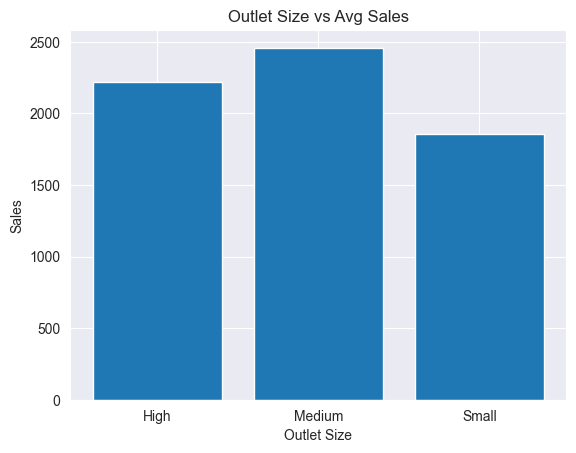

In [25]:
import matplotlib.pyplot as plt

size_sales = df.groupby('Outlet_Size')['Item_Outlet_Sales'].mean()

plt.bar(size_sales.index, size_sales.values)
plt.title("Outlet Size vs Avg Sales")
plt.xlabel("Outlet Size")
plt.ylabel("Sales")
plt.show()

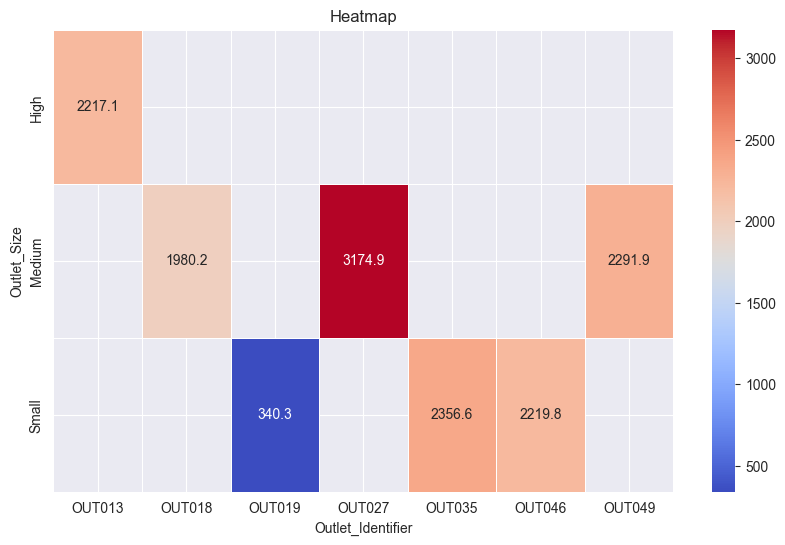

In [29]:
import seaborn as sns
heatmap_data=df.pivot_table(
    values='Item_Outlet_Sales',
    index='Outlet_Size',
    columns='Outlet_Identifier',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='coolwarm',
    linewidths=.5,
)

plt.title('Heatmap')
plt.show()

